Add salt and pepper noise

## 8. Fig. 4 is an image corrupted with salt and pepper noise.

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [35]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

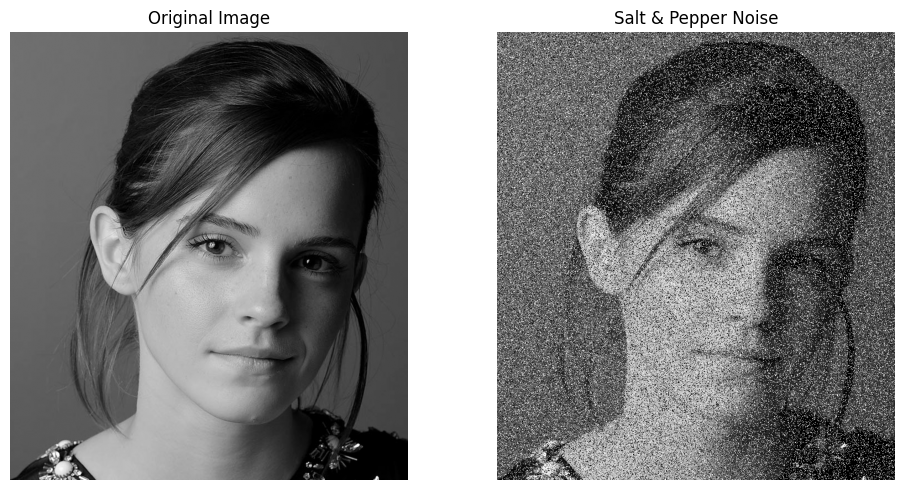

In [25]:
s = f.copy()
prob = 0.3 


salt = np.random.rand(*f.shape) < prob / 2
s[salt] = 255


pepper = np.random.rand(*f.shape) < prob / 2
s[pepper] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Salt & Pepper Noise')
ax[1].axis('off')
plt.tight_layout()
plt.show()

(a) Apply Gaussian smoothing

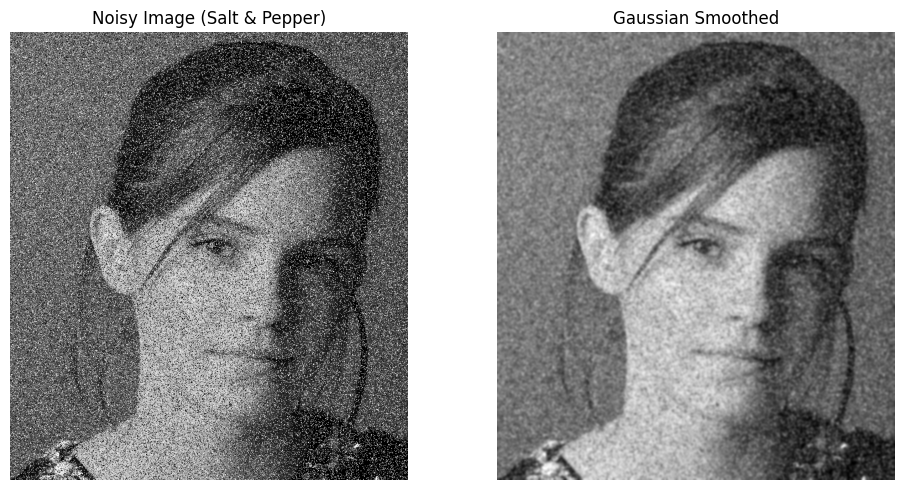

In [33]:
# For Kernel 13x13
sigma = 2
h_size = int(3 * sigma)

x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
g = g / np.sum(g)

# Apply Gaussian smoothing
gaussian_smoothed = cv.filter2D(s, -1, g)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(gaussian_smoothed, cmap='gray')
ax[1].set_title('Gaussian Smoothed')
ax[1].axis('off')

plt.tight_layout()
plt.show()

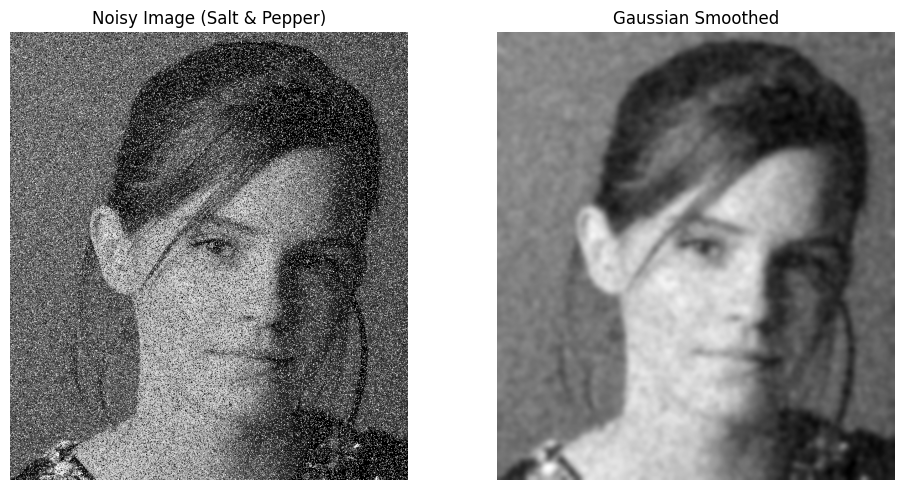

In [34]:
#For Kernel 31x31

sigma = 5
h_size = int(3 * sigma)

x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
g = g / np.sum(g)

# Apply Gaussian smoothing
gaussian_smoothed = cv.filter2D(s, -1, g)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(gaussian_smoothed, cmap='gray')
ax[1].set_title('Gaussian Smoothed')
ax[1].axis('off')

plt.tight_layout()
plt.show()

(b) Apply median filtering.

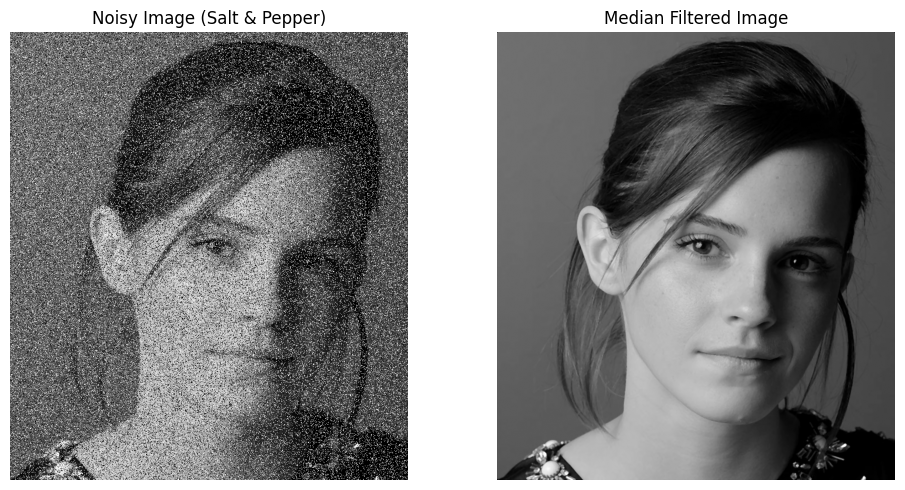

In [30]:
pad_size = 1  
padded = np.pad(f, pad_size, mode='constant')

output = np.zeros_like(f)


for i in range(s.shape[0]):
    for j in range(s.shape[1]):
        window = padded[i:i+3, j:j+3]
        output[i, j] = np.median(window)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(output, cmap='gray')
ax[1].set_title('Median Filtered Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()